/Users/halders2/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Simulating base Rössler trajectory...
Post-transient trajectory shape: (2500, 3)
Input matrix shape: (3, 10000)
Output matrix shape: (3, 10000)
Saved input_data_rossler.csv
Saved output_data_rossler.csv


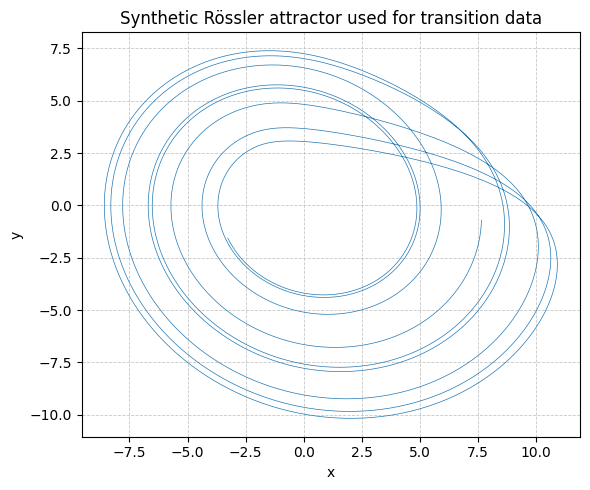

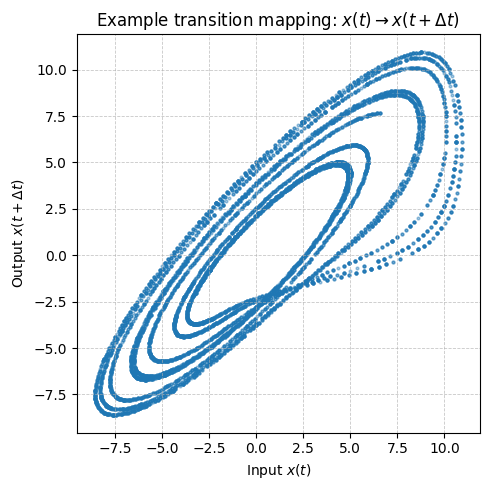

In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ============================================================
# SYNTHETIC RÖSSLER TRANSITION DATASET GENERATOR
# ============================================================

np.random.seed(42)

# Output files expected by your current code
input_csv = "input_data_rossler.csv"
output_csv = "output_data_rossler.csv"

# Number of independent samples / transitions
num_samples = 10000

# Rössler parameters: standard chaotic regime
a = 0.2
b = 0.2
c = 5.7

# Simulation settings
t_initial = 0.0
t_final = 120.0
transient_cutoff = 70.0

# Transition gap
# Input is state at t, output is state at t + delta_t
delta_t = 0.5

# Number of time points used internally for sampling candidate states
num_time_points = 6000

# Initial condition perturbation settings
base_initial_condition = np.array([0.1, 0.0, 0.0])
initial_noise_std = 1e-3

# ------------------------------------------------------------
# Rössler system
# ------------------------------------------------------------

def rossler_system(t, state, a, b, c):
    x, y, z = state

    dxdt = -y - z
    dydt = x + a * y
    dzdt = b + z * (x - c)

    return [dxdt, dydt, dzdt]


# ------------------------------------------------------------
# Generate one long trajectory after transient
# ------------------------------------------------------------

print("Simulating base Rössler trajectory...")

x0 = base_initial_condition + np.random.normal(
    0.0,
    initial_noise_std,
    size=3
)

t_eval = np.linspace(t_initial, t_final, num_time_points)

sol = solve_ivp(
    rossler_system,
    (t_initial, t_final),
    x0,
    t_eval=t_eval,
    args=(a, b, c),
    method="RK45",
    rtol=1e-9,
    atol=1e-12
)

if not sol.success:
    raise RuntimeError("Rössler integration failed.")

trajectory = sol.y.T
times = sol.t

# Keep only post-transient part
post_transient_mask = times >= transient_cutoff
trajectory_post = trajectory[post_transient_mask]
times_post = times[post_transient_mask]

print("Post-transient trajectory shape:", trajectory_post.shape)

# ------------------------------------------------------------
# Build input-output transition pairs
# ------------------------------------------------------------

inputs = []
outputs = []

valid_indices = []

for i in range(len(times_post)):
    target_time = times_post[i] + delta_t

    if target_time <= times_post[-1]:
        valid_indices.append(i)

valid_indices = np.array(valid_indices)

# Randomly sample transition starting points
chosen_indices = np.random.choice(
    valid_indices,
    size=num_samples,
    replace=True
)

for idx in chosen_indices:
    t_now = times_post[idx]
    t_target = t_now + delta_t

    # Find closest future index
    target_idx = np.argmin(np.abs(times_post - t_target))

    u = trajectory_post[idx]
    y = trajectory_post[target_idx]

    inputs.append(u)
    outputs.append(y)

inputs = np.asarray(inputs).T
outputs = np.asarray(outputs).T

print("Input matrix shape:", inputs.shape)
print("Output matrix shape:", outputs.shape)

# ------------------------------------------------------------
# Save in your current code's expected format
# Rows = variables, columns = samples
# First column is variable name, because your code skips column 0.
# ------------------------------------------------------------

input_df = pd.DataFrame(inputs)
output_df = pd.DataFrame(outputs)

input_df.insert(0, "variable", ["x_t", "y_t", "z_t"])
output_df.insert(0, "variable", ["x_t_plus_dt", "y_t_plus_dt", "z_t_plus_dt"])

input_df.columns = ["variable"] + [f"sample_{i+1}" for i in range(num_samples)]
output_df.columns = ["variable"] + [f"sample_{i+1}" for i in range(num_samples)]

input_df.to_csv(input_csv, index=False)
output_df.to_csv(output_csv, index=False)

print(f"Saved {input_csv}")
print(f"Saved {output_csv}")

# ------------------------------------------------------------
# Quick visualization
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))
plt.plot(trajectory_post[:, 0], trajectory_post[:, 1], linewidth=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Rössler attractor used for transition data")
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.savefig("synthetic_rossler_attractor_xy.jpeg", dpi=650, bbox_inches="tight")
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(inputs[0], outputs[0], s=4, alpha=0.4)
plt.xlabel(r"Input $x(t)$")
plt.ylabel(r"Output $x(t+\Delta t)$")
plt.title(r"Example transition mapping: $x(t) \rightarrow x(t+\Delta t)$")
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.savefig("synthetic_rossler_transition_scatter.jpeg", dpi=650, bbox_inches="tight")
plt.show()